In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns

files = {
    "Native": "/home/mengelsl/MA-bench-framework/benchmark/spmv_deep_analysis/n1.csv",
    "Native2": "/home/mengelsl/MA-bench-framework/benchmark/spmv_deep_analysis/n2.csv",
    "Native3": "/home/mengelsl/MA-bench-framework/benchmark/spmv_deep_analysis/n3.csv",
}
#CSV format:
#Matrix,Cores,Run,Type,Iteration,Runtime,Gflops
all_data = []
for name, path in files.items():
    df = pd.read_csv(path,index_col=False)
    df['Environment'] = name 
    all_data.append(df)

df = pd.concat(all_data, ignore_index=True)
df_iter=df[df['Type'] == 'ITER']
df_io=df[df['Type'] == 'IO_LOAD']

/tmp/ipykernel_805646/3648219966.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_iter['Unique_Run'] = df_iter['Environment'] + "_Run_" + df_iter['Run'].astype(str)


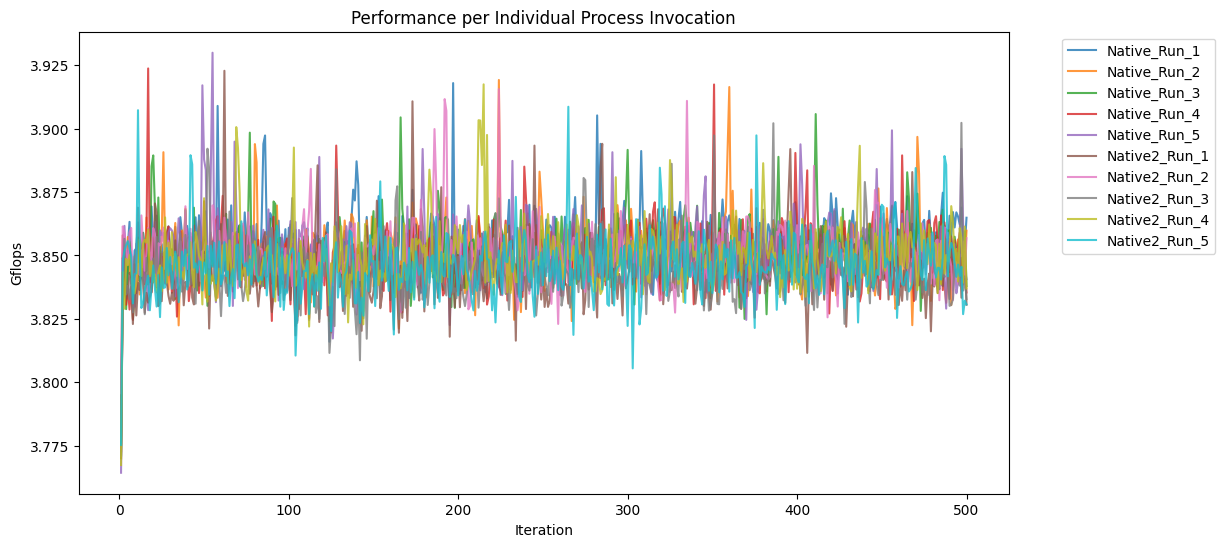

In [3]:
# Create a unique label for every single start
df_iter['Unique_Run'] = df_iter['Environment'] + "_Run_" + df_iter['Run'].astype(str)

# Plot using this unique ID
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.lineplot(
    data=df_iter, 
    x='Iteration', 
    y='Gflops', 
    hue='Unique_Run',  # This gives every line its own color
    alpha=0.8,
    linewidth=1.5
)

plt.title("Performance per Individual Process Invocation")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') # Move legend outside
plt.show()

In [9]:
import pandas as pd
import numpy as np

# 1. Filter für Native-Daten
df_n1 = df[df['Environment'] == 'Native']
df_n2 = df[df['Environment'] == 'Native2']
df_combined = pd.concat([df_n1, df_n2])

# 2. Gruppieren nach Matrix/Cores und die Standardabweichung (std) berechnen
# Wir schauen uns an: std von Run 1, std von Run 2 und std von beiden zusammen
std_n1 = df_n1.groupby(['Matrix', 'Cores'])['Gflops'].std()
std_n2 = df_n2.groupby(['Matrix', 'Cores'])['Gflops'].std()
std_all = df_combined.groupby(['Matrix', 'Cores'])['Gflops'].std()

# 3. Vergleich
# Wenn std_all deutlich größer ist als std_n1 oder std_n2, 
# dann hat der Neustart zwischen den Runs eine neue Varianzquelle eingeführt.
comparison = pd.DataFrame({
    'Std_Native1': std_n1,
    'Std_Native2': std_n2,
    'Std_Combined': std_all,
    'Increase_Factor': std_all / ((std_n1 + std_n2) / 2)
})

print("Varianz-Vergleich: Einzelne Runs vs. Kombiniert")
print(comparison.round(4))

Varianz-Vergleich: Einzelne Runs vs. Kombiniert
                         Std_Native1  Std_Native2  Std_Combined  \
Matrix            Cores                                           
0-0_N1008246.bin  8           0.2619       0.2678        0.2730   
                  24          0.8902       0.9027        0.9237   
                  48          1.5800       1.6129        1.5990   
                  72          4.5049       4.6897        5.2495   
0-0_N17284220.bin 8           0.2600       0.2669        0.2742   
                  24          0.6216       0.6258        0.6254   
                  48          0.6744       0.6798        0.6774   
                  72          2.6496       2.6433        2.6462   
0-0_N28807.bin    8           1.2352       1.2603        1.2435   
                  24          4.0493       3.8465        3.9826   
                  48          5.3390       5.6407        5.4411   
                  72          5.0773       5.1041        5.0873   
1-0_N432105.bi